# Robust Yöntemlere Örnekler

**Senaryo 1**</br>

* Gerçek ilişki: y=2x+1
* Veri içine bilerek güçlü outlier’lar ekleniyor
* OLS ve RANSAC sonuçları karşılaştırılıyor


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, RANSACRegressor


In [2]:
# Outlier’lı Veri Oluşturma

np.random.seed(42)

# Temel lineer veri
X = np.random.uniform(0, 10, 100)
y = 2 * X + 1 + np.random.normal(0, 1, size=100)

# Outlier ekleyelim
X_outliers = np.random.uniform(0, 10, 15)
y_outliers = np.random.uniform(30, 50, 15)   # ilişkiyi bozan uç değerler

# Birleştirme
X_all = np.concatenate([X, X_outliers])
y_all = np.concatenate([y, y_outliers])

X_all = X_all.reshape(-1, 1)


In [4]:
# Klasik OLS Regresyon

ols = LinearRegression()
ols.fit(X_all, y_all)

y_pred_ols = ols.predict(X_all)


**RANSAC Regression**

* Rastgele küçük alt örnekler seçer
* Bu alt örneklerle model kurar
* Modele uyan noktaları(inlier) belirler
* En çok inlier’a sahip modeli seçer
* Outlier’ları otomatik dışlar

In [5]:
ransac = RANSACRegressor(
    estimator=LinearRegression(),
    min_samples=50,
    residual_threshold=3.0,
    random_state=42
)

ransac.fit(X_all, y_all)

y_pred_ransac = ransac.predict(X_all)

inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)


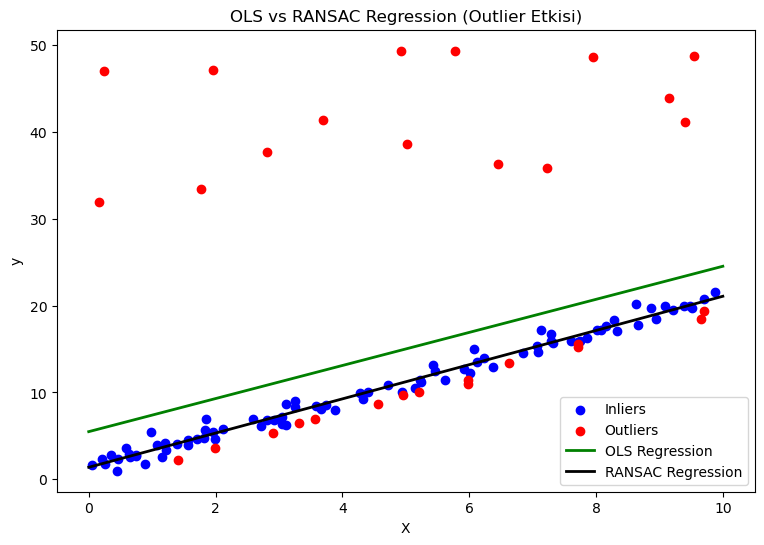

In [6]:
# Sonuçların Görselleştirilmesi
plt.figure(figsize=(9,6))

# Gerçek veriler
plt.scatter(X_all[inlier_mask], y_all[inlier_mask],
            color="blue", label="Inliers")
plt.scatter(X_all[outlier_mask], y_all[outlier_mask],
            color="red", label="Outliers")

# Regresyon çizgileri
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
plt.plot(x_line, ols.predict(x_line),
         color="green", linewidth=2, label="OLS Regression")

plt.plot(x_line, ransac.predict(x_line),
         color="black", linewidth=2, label="RANSAC Regression")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("OLS vs RANSAC Regression (Outlier Etkisi)")
plt.show()


In [7]:
# Katsayıların Karşılaştırılması

print("OLS coef:", ols.coef_[0], "Intercept:", ols.intercept_)
print("RANSAC coef:", ransac.estimator_.coef_[0],
      "Intercept:", ransac.estimator_.intercept_)


OLS coef: 1.9038450827644668 Intercept: 5.48292924646179
RANSAC coef: 1.9685958845835707 Intercept: 1.3810372770274029


**OLS neden başarısız?**

OLS, hata karelerini minimize eder:</br>

$
\text{SSE} = \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
$
</br>
Outlier’ların hatası kare alındığı için aşırı büyür → model onlara uymaya çalışır.</br>

**RANSAC neden başarılı?**

* Outlier’ları en baştan model dışı bırakır
* “Çoğunluğa uyan modeli” seçer
* Bu nedenle robusttur


**Senaryo 2**</br>

* Değişken: Aylık gelir (₺)
* Veri içinde birkaç çok büyük gelir outlier’ı var
* Ama bu gözlemler gerçek kişilere ait olabileceği için silinmek istenmiyor


**Winsorization (İstatistiksel Doluluk) Nedir?**

Winsorization, aşırı uç değerleri (outlier) silmez; belirlenen alt ve üst yüzdelik (percentile) sınırlarına kırpar (clip eder).</br>

Örneğin:</br>
* %5 altındaki değerler → %5 yüzdeliğe çekilir
* %95 üzerindeki değerler → %95 yüzdeliğe çekilir

Böylece:</br>
* Veri setinin boyutu korunur
* Aşırı değerlerin modele verdiği zarar azaltılır

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [10]:
# Outlier içeren veri seti hazırlanıyor

np.random.seed(42)

# Normal gelirler
income_normal = np.random.normal(loc=15000, scale=3000, size=200)

# Aşırı uç gelirler (outlier)
income_outliers = np.array([80000, 90000, 120000, 150000])

income = np.concatenate([income_normal, income_outliers])

df = pd.DataFrame({"income": income})
df.describe().T


,count,mean,std,min,25%,50%,75%,max
income,204.0,16742.830495,14043.516576,7140.764688,12943.404556,15106.815915,16660.902918,150000.0


In [11]:
# Percentile Tabanlı Winsorization Uygulaması 
# %5 – %95 Winsorization

lower = df["income"].quantile(0.05)
upper = df["income"].quantile(0.95)

df["income_winsor"] = df["income"].clip(lower=lower, upper=upper)

# clip() → pandas’ın Winsorization karşılığıdır
# Alt ve üst sınırların dışına çıkan değerler sınırda sabitlenir

In [15]:
# Özet İstatistikler
df[["income", "income_winsor"]].describe()

# Dikkat edilmesi gerekenler:,
# Ortalama (mean) düşer
# Standart sapma azalır
# Medyan genelde değişmez



,income,income_winsor
count,204.000000,204.000000
mean,16742.830495,15010.219704
std,14043.516576,2688.217755
min,7140.764688,10571.187198
25%,12943.404556,12943.404556
50%,15106.815915,15106.815915
75%,16660.902918,16660.902918
max,150000.000000,20433.955137


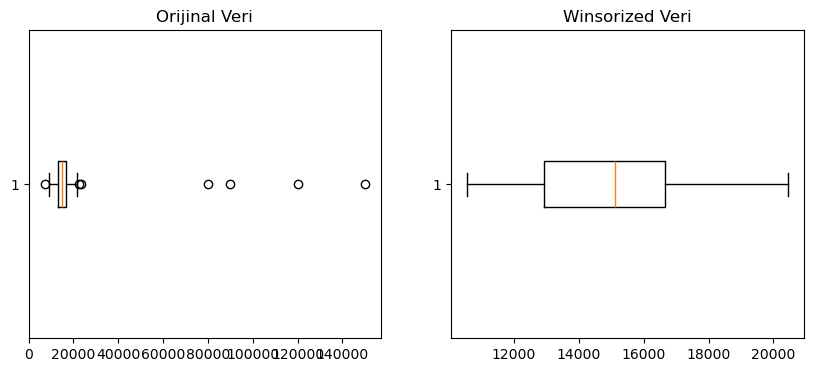

In [16]:
# Görselleştirme ile Sonuçlar Karşılaştırılıyor

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df["income"], vert=False)
plt.title("Orijinal Veri")

plt.subplot(1,2,2)
plt.boxplot(df["income_winsor"], vert=False)
plt.title("Winsorized Veri")

plt.show()

# Outlier’lar artık dağılımı bozmamaktadır
# Gözlem sayısı korunur

In [17]:
# Winsorized değişkeni modele sokulur

X = df[["income_winsor"]]

# Model daha stabil
# Katsayılar daha güvenilir,
# OLS varsayımları daha az ihlal edilir.

| Yöntem           | Ne yapar              | Risk                  |
| ---------------- | --------------------- | --------------------- |
| Drop             | Outlier’ı siler       | Bilgi kaybı           |
| Winsorization    | Etkisini sınırlar     | Dağılım biraz bozulur |
| Robust Regresyon | Model düzeyinde çözer | Yorum zorlaşır        |
